# QoSBuddy — M6: DSO3.2 RAG + GenAI + Dashboard Demo  
**ESPRIT - PingWin Team | Member 6**

This notebook demonstrates the full M6 pipeline step by step:  
1. Load all upstream module outputs (M1 + M3 data)  
2. Build the ChromaDB knowledge base  
3. Test semantic retrieval  
4. Generate a NOC-style RAG answer via Ollama  
5. Preview KPI visualizations + launch the Streamlit dashboard

In [1]:
import sys
!{sys.executable} -m pip install -q \
    chromadb sentence-transformers langchain langchain-ollama \
    plotly pypdf reportlab
print('✅ All dependencies installed')

✅ All dependencies installed


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [3]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Point to data directory
os.environ['QOSBUDDY_DATA_DIR'] = './data'
DATA_DIR = './data'

print('✅ Libraries loaded')

✅ Libraries loaded


In [5]:
# Load M1 output: anomaly_scores_ns3.xls
df_anomaly = pd.read_csv(f'{DATA_DIR}/anomaly_scores_ns3.xls')

# Clean duplicate columns if any
dupe_cols = [c for c in df_anomaly.columns if c.endswith('.1')]
df_anomaly = df_anomaly.drop(columns=dupe_cols)
df_anomaly['ae_error'] = df_anomaly['ae_error'].fillna(0.0)

print(f'Anomaly data shape: {df_anomaly.shape}')
print(f'Severity distribution:\n{df_anomaly["severity"].value_counts()}')
df_anomaly.head(3)

Anomaly data shape: (17525, 28)
Severity distribution:
severity
critical    9341
degraded    5643
normal      2541
Name: count, dtype: int64


,ue_id,timestamp,load_level,mobility_speed,shadowing_enabled,severity,sinr_dl_db,mcs_dl,throughput_mbps,delay_ms,...,packet_loss_ratio_roll5_mean,packet_loss_ratio_roll5_std,jitter_ms_roll5_mean,throughput_mbps_roll5_mean,packet_loss_ratio_spike,sinr_dl_db_spike,if_score,if_anomaly,ae_error,ae_anomaly
0,1,1,1,0,0,critical,-20.51350,0,0.058944,268.8860,...,0.970000,0.000000,4.166670,0.058944,0,0,0.429050,0,0.0,0
1,1,1,1,0,1,normal,8.10462,12,1.905860,4.8835,...,0.500000,0.664680,2.175198,0.982402,0,0,0.581964,1,0.0,0
2,1,1,2,0,0,critical,-14.65900,0,0.117888,347.0290,...,0.656667,0.542709,17.335065,0.694231,0,0,0.413402,0,0.0,0


In [7]:
# Load M3 output 1: root_cause_labels.csv
df_causal = pd.read_csv(f'{DATA_DIR}/root_cause_labels.csv')
print('Root causes found:', df_causal['root_cause'].unique())
print('Recommended actions:', df_causal['recommended_action'].unique())

# Load M3 output 2: counterfactuals.csv
df_cf = pd.read_csv(f'{DATA_DIR}/counterfactuals.csv')
print(f'\nCounterfactual: {df_cf["reduction_pct"].mean():.1f}% avg packet loss reduction possible')

df_causal.head(3)

Root causes found: ['interference' 'mobility' 'combined/other' 'congestion']
Recommended actions: ['frequency_reallocation + power_control'
 'handover_optimization + beam_tracking'
 'multi-action (reroute + prioritize)'
 'load_balancing + traffic_throttling']

Counterfactual: 49.7% avg packet loss reduction possible


,timestamp,severity,if_anomaly,root_cause,recommended_action,packet_loss_ratio
0,1,critical,0,interference,frequency_reallocation + power_control,0.97
1,1,normal,1,interference,frequency_reallocation + power_control,0.03
2,1,critical,0,interference,frequency_reallocation + power_control,0.97


  Avg Jitter (ms)               : 37.767
  Avg Packet Loss (%)           : 77.775
  Avg Throughput (Mbps)         : 0.981
  Avg Delay (ms)                : 229.227
  Anomaly Rate (%)              : 35.001


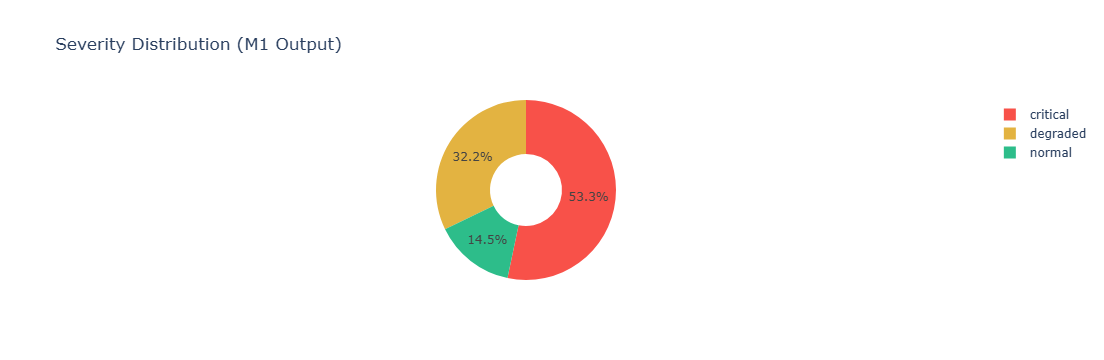

In [9]:
# Quick KPI summary
avg_metrics = {
    'Avg Jitter (ms)':       df_anomaly['jitter_ms'].mean(),
    'Avg Packet Loss (%)':    df_anomaly['packet_loss_ratio'].mean() * 100,
    'Avg Throughput (Mbps)':  df_anomaly['throughput_mbps'].mean(),
    'Avg Delay (ms)':         df_anomaly['delay_ms'].mean(),
    'Anomaly Rate (%)':       df_anomaly['if_anomaly'].mean() * 100,
}
for k, v in avg_metrics.items():
    print(f'  {k:30s}: {v:.3f}')

# Severity pie chart
fig = px.pie(
    df_anomaly['severity'].value_counts().reset_index(),
    names='severity', values='count',
    color='severity',
    color_discrete_map={'critical':'#f85149','degraded':'#e3b341','normal':'#2dbd8a'},
    title='Severity Distribution (M1 Output)',
    hole=0.4,
)
fig.show()

In [11]:
import sys
sys.path.insert(0, '.')

from rag.build_knowledge_base import build_knowledge_base

client, collection = build_knowledge_base()
print(f'✅ Knowledge base ready: {collection.count()} documents')

2026-03-29 14:34:20,886 [INFO] ============================================================
2026-03-29 14:34:20,887 [INFO] QoSBuddy M6 — Knowledge Base Builder (DSO3.2)
2026-03-29 14:34:20,888 [INFO] ============================================================
2026-03-29 14:39:40,338 [INFO] Deleted existing collection 'qosbuddy_knowledge' for fresh build
2026-03-29 14:39:40,360 [INFO] Loading embedding model: all-MiniLM-L6-v2
2026-03-29 14:39:40,369 [INFO] Use pytorch device_name: cpu
2026-03-29 14:39:40,370 [INFO] Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2026-03-29 14:39:40,653 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-29 14:39:40,681 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-03-29 14:39:40,818 [INFO] HTTP Request:

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-29 14:39:42,437 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-29 14:39:42,462 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config.json "HTTP/1.1 200 OK"
2026-03-29 14:39:42,598 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-29 14:39:42,623 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all

✅ Knowledge base ready: 17578 documents


In [15]:
# ──────────────────────────────────────────────────────────────
# Cell 8 — Test Semantic Retrieval (FIXED VERSION)
# ──────────────────────────────────────────────────────────────
from rag.rag_pipeline import get_chroma_collection, get_embed_model

collection  = get_chroma_collection()
embed_model = get_embed_model()

query = 'critical anomaly caused by congestion with high packet loss'

# Manual query with proper ChromaDB $and syntax (bypasses the bug)
results = collection.query(
    query_texts=[query],
    n_results=3,
    where={
        "$and": [
            {"doc_type": {"$eq": "ANOMALY_EVENT"}},
            {"severity": {"$eq": "critical"}}
        ]
    },
    include=["documents", "metadatas", "distances"]
)

# Convert to the same format the original function returns
docs = []
for i in range(len(results["documents"][0])):
    docs.append({
        "document": results["documents"][0][i],
        "similarity": 1 - results["distances"][0][i],   # convert distance to similarity
        "metadata": results["metadatas"][0][i]
    })

print(f'✅ Retrieved {len(docs)} documents for query: "{query}"\n')
for i, d in enumerate(docs, 1):
    print(f'--- Document {i} (similarity={d["similarity"]:.3f}) ---')
    print(d['document'][:500] + "..." if len(d['document']) > 500 else d['document'])
    print()

2026-03-29 14:52:49,802 [INFO] Use pytorch device_name: cpu
2026-03-29 14:52:49,803 [INFO] Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2026-03-29 14:52:50,036 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-29 14:52:50,066 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-03-29 14:52:50,201 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-29 14:52:50,226 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-03-29 14:52:50,358 [INFO] HTTP Request: HEAD h

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-29 14:52:51,374 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-29 14:52:51,403 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config.json "HTTP/1.1 200 OK"
2026-03-29 14:52:51,548 [INFO] HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-29 14:52:51,576 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all

✅ Retrieved 3 documents for query: "critical anomaly caused by congestion with high packet loss"

--- Document 1 (similarity=0.536) ---
[ANOMALY EVENT] UE 2 | Timestamp 308 | Severity: 🔴 CRITICAL
─────────────────────────────────────────────────────────────────────
Detection:
  • Isolation Forest flagged: NO (score 0.3894)
  • LSTM Autoencoder flagged: NO (error 0.3494)
  • Consensus anomaly: ❌ NO ANOMALY

KPI Snapshot:
  • SINR (DL):       -11.86 dB   ⚠️ POOR (<0 dB)
  • Throughput:      0.088 Mbps  🔴 CRITICAL (<0.5 Mbps)
  • Delay:           869.78 ms   🔴 HIGH (>100ms)
  • Jitter:          53.040 ms  ⚠️ HIGH (>10ms)
  • Packet...

--- Document 2 (similarity=0.533) ---
[ANOMALY EVENT] UE 1 | Timestamp 783 | Severity: 🔴 CRITICAL
─────────────────────────────────────────────────────────────────────
Detection:
  • Isolation Forest flagged: NO (score 0.4152)
  • LSTM Autoencoder flagged: NO (error 0.5782)
  • Consensus anomaly: ❌ NO ANOMALY

KPI Snapshot:
  • SINR (DL):       -14.59 dB   

In [17]:
from rag.rag_pipeline import build_langchain_rag_chain, query_rag

chain = build_langchain_rag_chain(collection, embed_model)

result = query_rag(
    question='What is causing critical anomalies in the network and what should the NOC do?',
    collection=collection,
    embed_model=embed_model,
    chain=chain,
    mode='causal',
)

print('=== NOC ANSWER ===\n')
print(result['answer'])
print(f'\n=== SOURCES ({len(result["sources"])} documents retrieved) ===')
for s in result['sources']:
    print(f'  - {s["metadata"]["doc_type"]} | sim={s["similarity"]:.3f} | sev={s["metadata"].get("severity","?")} | rc={s["metadata"].get("root_cause","?")}')

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-29 14:59:44,833 [INFO] HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"


=== NOC ANSWER ===

**🚨 Alert Summary:**
Critical congestion anomalies detected across multiple UEs, with peak packet loss reaching 100.0% and critical severity rate at 79.8%. The affected UEs are those with high load levels.

**✅ Recommended Action:**
Apply load_balancing + traffic_throttling to mitigate congestion and reduce packet loss.

**📊 Counterfactual Impact:**
49.7% reduction in packet loss possible if recommended action is applied.

**🎯 Confidence:** HIGH

=== SOURCES (4 documents retrieved) ===
  - CAUSAL_INSIGHT | sim=0.535 | sev=? | rc=congestion
  - CAUSAL_INSIGHT | sim=0.500 | sev=? | rc=combined/other
  - CAUSAL_INSIGHT | sim=0.483 | sev=? | rc=interference
  - CAUSAL_INSIGHT | sim=0.427 | sev=? | rc=mobility


In [19]:
causal_summary = df_causal.groupby(['root_cause','recommended_action']).agg(
    event_count=('if_anomaly','count'),
    anomaly_rate=('if_anomaly','mean'),
    avg_packet_loss=('packet_loss_ratio','mean'),
    critical_pct=('severity', lambda x: (x=='critical').mean()),
).reset_index()

print('=== Causal Root Cause Summary (M3 DSO1.2 Output) ===')
print(causal_summary.to_string(index=False))
print()
print(f'Counterfactual: applying corrective actions reduces packet loss by')
print(f'  {df_cf["reduction_pct"].mean():.1f}% on average (M3 DoWhy ATE estimate)')

=== Causal Root Cause Summary (M3 DSO1.2 Output) ===
    root_cause                     recommended_action  event_count  anomaly_rate  avg_packet_loss  critical_pct
combined/other    multi-action (reroute + prioritize)         3507      0.671229         0.368584      0.071856
    congestion    load_balancing + traffic_throttling         3810      0.502625         0.888517      0.653281
  interference frequency_reallocation + power_control         9913      0.158378         0.903059      0.665792
      mobility  handover_optimization + beam_tracking          295      1.000000         0.000395      0.000000

Counterfactual: applying corrective actions reduces packet loss by
  49.7% on average (M3 DoWhy ATE estimate)


In [ ]:
import subprocess, sys, os

env = os.environ.copy()
env['QOSBUDDY_DATA_DIR'] = './data'

proc = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run',
     'dashboard/streamlit_dashboard.py',
     '--server.port=8501', '--server.headless=true'],
    env=env,
)

print('Dashboard starting...')
print('Open in browser: http://localhost:8501')
print(f'Process PID: {proc.pid} (run proc.terminate() to stop)')